In [1]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
import pickle as pkl
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce
from utils_plot import plot_pca

import shutil
from joblib import Parallel, delayed



In [2]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [3]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
C.linear_net = False
C.learning_rate = 0.0001
C.L=3
C.print_progress = True
C.algo_name = 'Adam'
C.loss_fn = nn.CrossEntropyLoss()
C.length_corridors = [20]*1
C.max_move = 5
# C.input_size = 10
C.hidden_size = 100 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1000000
C.mix_inputs = 1
# C.mix_outputs = 0.9

var_name = 'L'
var_values = [1,2,3,4,5,6] # np.arange(1, C.length_corridors[0]-1)

In [4]:
num_gpus = 8

# Ensure the results directory exists
results_dir = f'results/notebook_results/circular/{var_name}'
if os.path.exists(results_dir):
    shutil.rmtree(results_dir)
os.makedirs(results_dir, exist_ok=True)

def run_and_save(var_value, index):
    C_local = deepcopy(C)
    setattr(C_local, var_name, var_value)
    if var_name == 'L':
        C_local.learning_rate = C.learning_rate * 0.2**C_local.L
    C_local.gpu_id = index % num_gpus
    data_dict = run_sim_wrapper(C_local)
    out_path = os.path.join(results_dir, f'data_dict_{index}.pkl')
    # Remove 'state_dict_l' and 'hidden_l' from data_dict if they exist
    data_dict.pop('state_dict_l', None)
    data_dict.pop('hidden_l', None)
    with open(out_path, 'wb') as f:
        pkl.dump(data_dict, f)
    return out_path

# Run in parallel
paths = Parallel(n_jobs=-1)(
    delayed(run_and_save)(var_value, index) for index, var_value in enumerate(var_values)
)
# Load all results into data_dict_l
data_dict_l = []
for path in paths:
    with open(path, 'rb') as f:
        data_dict_l.append(pkl.load(f))

for data_dict in data_dict_l:
    print(f'{var_name}: {getattr(data_dict["C"], var_name)} --- X shape: {data_dict["X"].shape} --- Number of hidden: {data_dict["C"].hidden_size}')

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Number of samples: 190
Input dimension: 31
Output dimension: 20
Number of actions: 11

Variance of last hidden: 2.30e-04, of output: 6.47e-04
Variance of last hidden: 4.79e-03, of output: 1.17e-02
Variance of last hidden: 8.16e-05, of output: 1.17e-04
Variance of last hidden: 1.50e-05, of output: 3.37e-05
Variance of last hidden: 3.86e-06, of output: 1.04e-05Variance of last hidden: 1.01e-03, of output: 1.96e-03



  6%|▌         | 58874/1000000 [02:01<32:26, 483.43it/s]  


KeyboardInterrupt: 

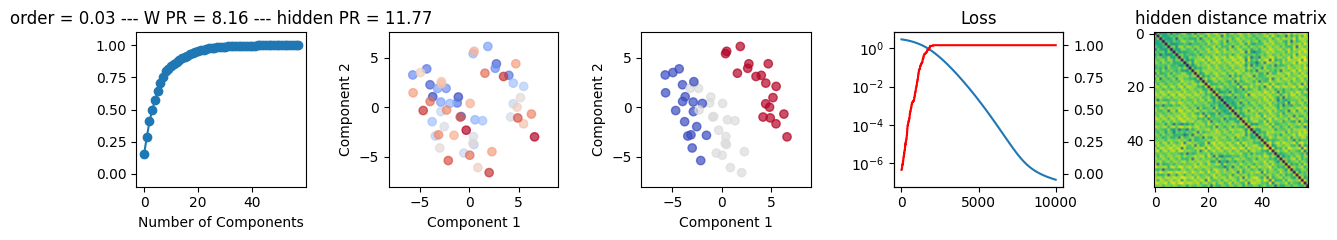

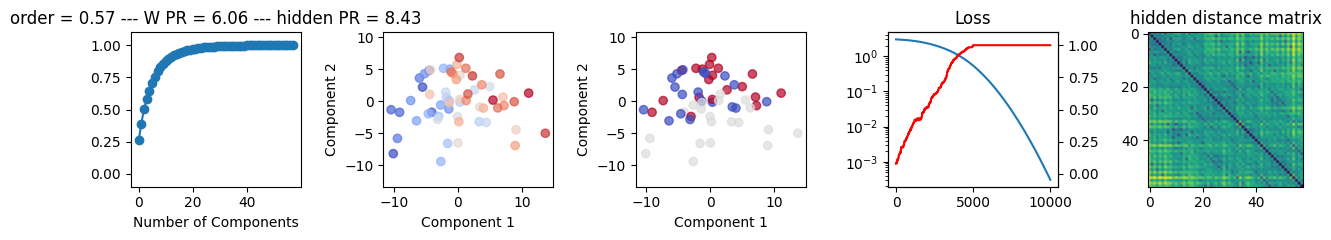

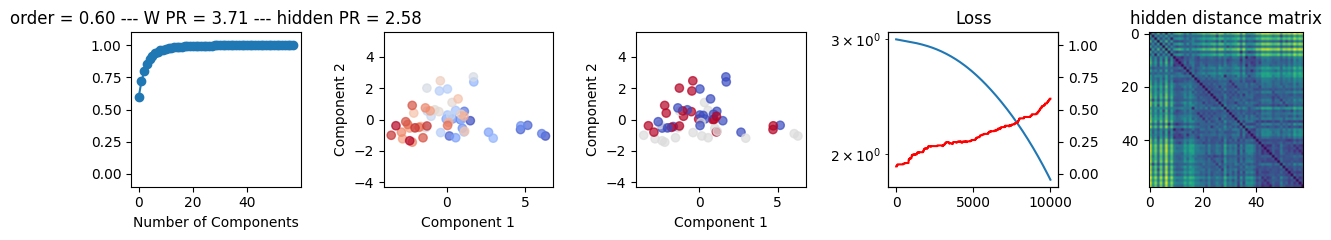

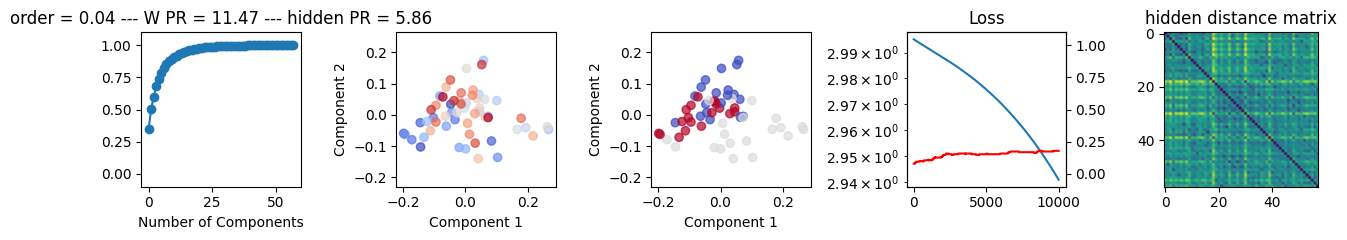

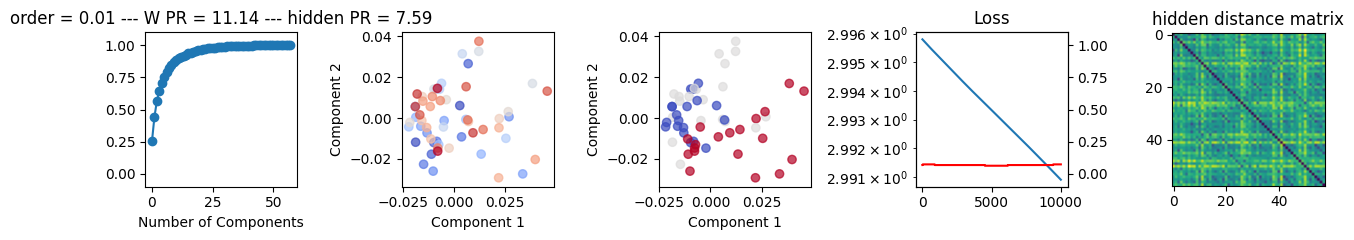

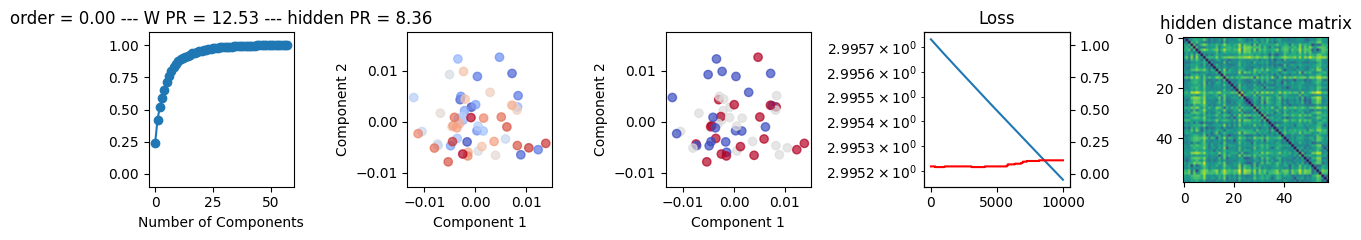

In [ ]:
from utils_plot import plot_pca
for data_dict in data_dict_l:
    plot_pca(data_dict, action_filter=1)

In [ ]:
def calc_metrics(data_dict, i=-1, action_filter=None):
    hidden = data_dict['hidden_states'][i].cpu().detach().numpy()
    loc_y = data_dict['loc_y']
    if action_filter is not None:
        action_taken = data_dict['action_taken']
        hidden = hidden[abs(action_taken)<=action_filter]
        loc_y = loc_y[abs(action_taken)<=action_filter]
    PR = calc_PR(hidden)
    order = get_r_2(PCA(n_components=1).fit_transform(hidden), loc_y)
    return PR, order

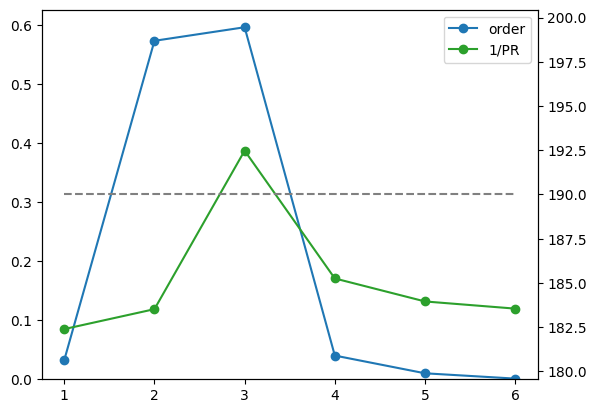

In [ ]:
PR_l = []
order_l = []
n_samples_l = []
for data_dict in data_dict_l:
    PR, order = calc_metrics(data_dict, action_filter=1)
    PR_l.append(1/PR)
    order_l.append(order)
    n_samples_l.append(data_dict['X'].shape[0])
plt.plot(var_values, order_l, label='order', marker='o')   
plt.plot(var_values, PR_l, label='1/PR', marker='o', c='tab:green')
plt.legend()
plt.ylim(0)
plt.axhline(1, color='gray', linestyle='--', alpha=0.5)
plt.gca().twinx().plot(var_values, n_samples_l, ls='--', c='gray')
plt.show()

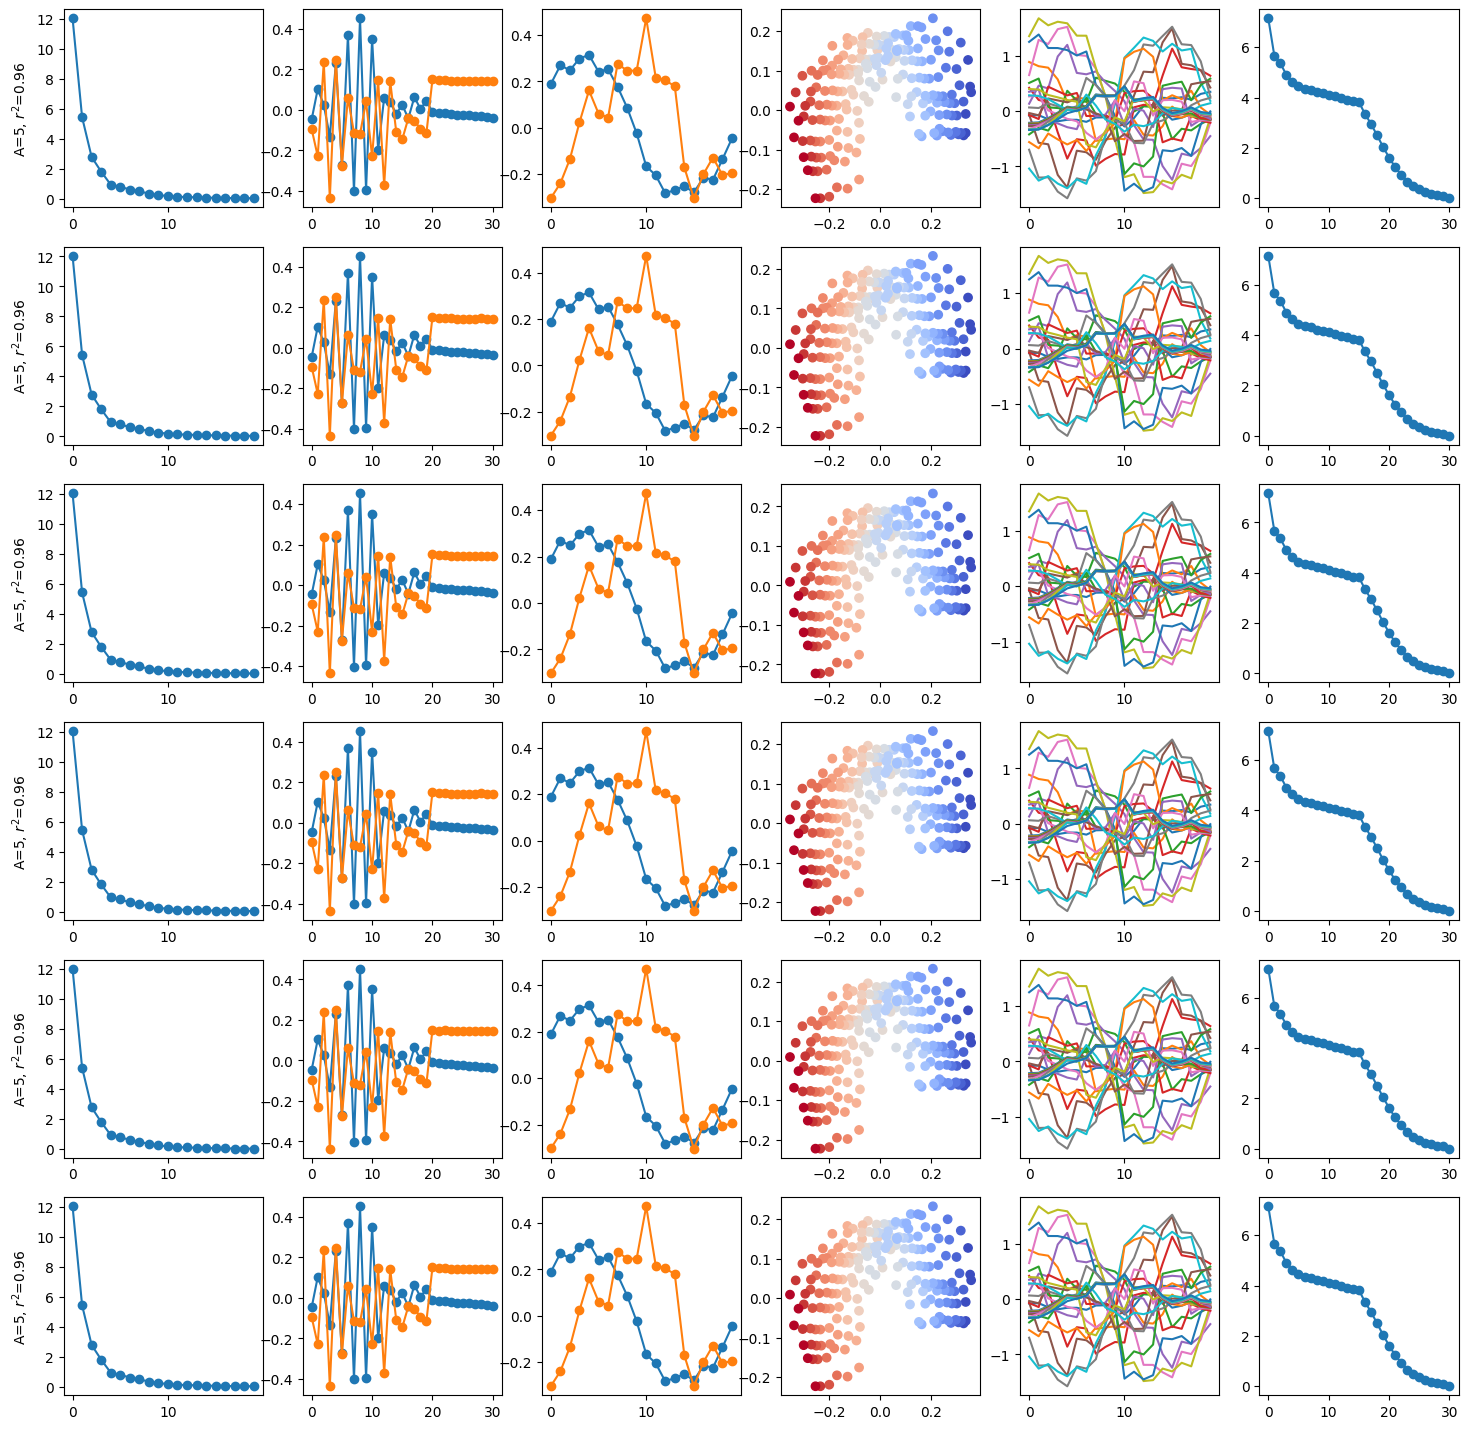

In [ ]:
fig, axs_all = plt.subplots(len(data_dict_l),6,figsize=(3*6,3*len(data_dict_l)))
for i, data_dict in enumerate(data_dict_l):
    axs = axs_all[i]
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    loc_X = data_dict['loc_X']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    C = data_dict['C']
    length = C.length_corridors[0]
    A = C.max_move
    X_p = (np.linalg.pinv(X.T @ X) @ X.T)
    Ux, Sx, Vx = np.linalg.svd(X)
    X_p2 = Ux[:,[-1]] @ Vx[[-1],:]
    vx = Vx[[-1], :].T 
    OLS = np.linalg.pinv(X.T @ X) @ X.T @ y
    U, S, V = np.linalg.svd(OLS, full_matrices=False)
    hidden = X@U@np.diag(S)
    r2 = get_r_2(hidden[abs(action_taken)<=100,:1], loc_y[abs(action_taken)<=100])
    axs[0].plot(S, marker = 'o')
    axs[0].set_ylabel(f'A={A}, $r^2$={r2:.2f}')
    for i in range(2):
        axs[1].plot(U[:,i], marker = 'o')
        axs[2].plot(V[i,:], marker = 'o')
    axs[3].scatter(X@U[:,0]*S[0], X@U[:,1]*S[1], c=loc_y, cmap='coolwarm')
    axs[4].plot(OLS.T)
    axs[5].plot(Sx, marker='o')


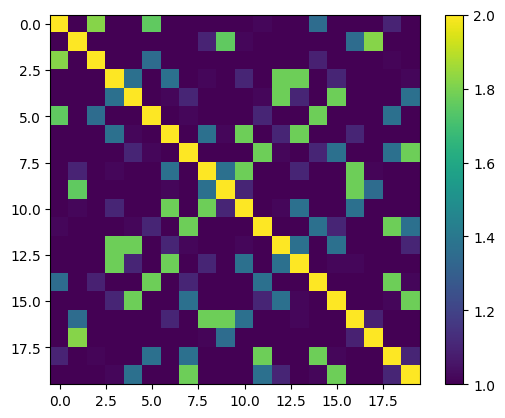

In [ ]:
X = data_dict['X'].cpu().numpy()[data_dict['action_taken']==0]
plt.imshow(X@X.T)
plt.colorbar()

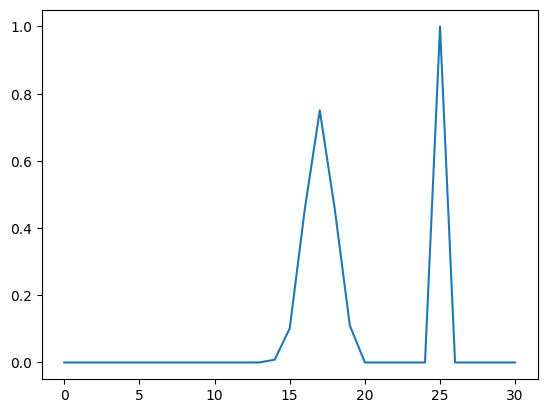

In [ ]:
plt.plot(X[5])